Reference CD (lc=15.0): 0.057321

    lc            CD     % change from lc=15
---------------------------------------------
 15.00      0.057321                +0.0000%
 10.00      0.059528                +3.8489%
  7.50      0.065524               +14.3099%
  5.00      0.073231               +27.7551%
  3.75      0.075346               +31.4449%
  2.50      0.077467               +35.1460%


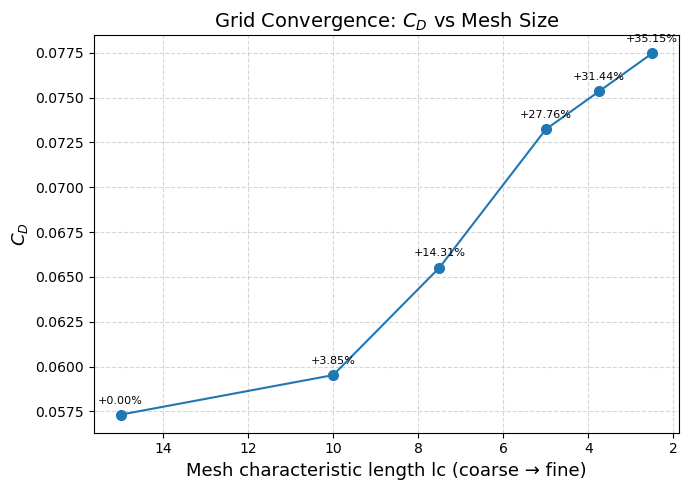

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_dir = os.path.dirname(os.path.abspath("gridconv.ipynb"))

folders = [
    ("lc=15",  15.0),
    ("lc=10",  10.0),
    ("lc=7.5",  7.5),
    ("lc=5.0",  5.0),
    ("3.75",    3.75),
    ("lc=2.5",  2.5),
]

lc_vals, cd_vals = [], []

for folder, lc in folders:
    csv_path = os.path.join(base_dir, folder, "history_m1.csv")
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.strip('"')
    last_cd = df["CD"].iloc[-1]
    lc_vals.append(lc)
    cd_vals.append(last_cd)

# Sort coarse → fine (large lc to small lc)
pairs = sorted(zip(lc_vals, cd_vals), reverse=True)
lc_sorted, cd_sorted = zip(*pairs)

# Percentage change relative to coarsest mesh (lc=15)
cd_ref = cd_sorted[0]
print(f"Reference CD (lc={lc_sorted[0]}): {cd_ref:.6f}\n")
print(f"{'lc':>6}  {'CD':>12}  {'% change from lc=15':>22}")
print("-" * 45)
for lc, cd in zip(lc_sorted, cd_sorted):
    pct = (cd - cd_ref) / abs(cd_ref) * 100
    print(f"{lc:>6.2f}  {cd:>12.6f}  {pct:>+21.4f}%")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lc_sorted, cd_sorted, "o-", markersize=7)

# Annotate % change at each point
for lc, cd in zip(lc_sorted, cd_sorted):
    pct = (cd - cd_ref) / abs(cd_ref) * 100
    ax.annotate(f"{pct:+.2f}%", xy=(lc, cd), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

ax.set_xlabel("Mesh characteristic length lc (coarse → fine)", fontsize=13)
ax.set_ylabel("$C_D$", fontsize=13)
ax.set_title("Grid Convergence: $C_D$ vs Mesh Size", fontsize=14)
ax.invert_xaxis()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Reference CMz (lc=15.0): 0.141736

    lc           CMz     % change from lc=15
---------------------------------------------
 15.00      0.141736                +0.0000%
 10.00      0.141622                -0.0806%
  7.50      0.140553                -0.8347%
  5.00      0.145860                +2.9092%
  3.75      0.141803                +0.0472%
  2.50      0.141228                -0.3586%


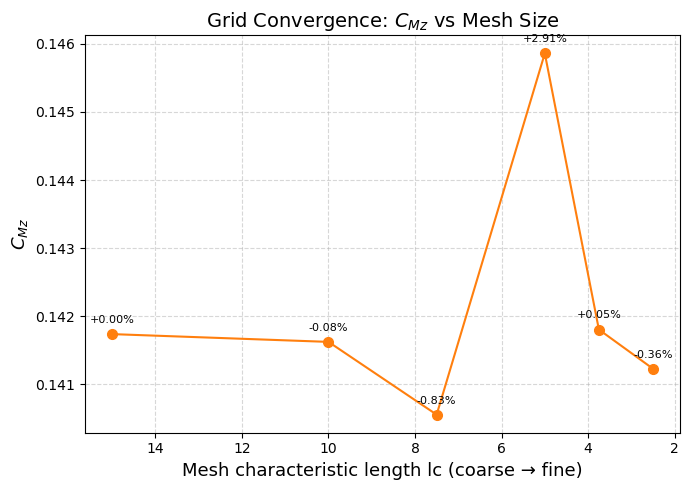

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_dir = os.path.dirname(os.path.abspath("gridconv.ipynb"))

folders = [
    ("lc=15",  15.0),
    ("lc=10",  10.0),
    ("lc=7.5",  7.5),
    ("lc=5.0",  5.0),
    ("3.75",    3.75),
    ("lc=2.5",  2.5),
]

lc_vals, cmz_vals = [], []

for folder, lc in folders:
    csv_path = os.path.join(base_dir, folder, "history_m1.csv")
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.strip('"')
    last_cmz = df["CMz"].iloc[-1]
    lc_vals.append(lc)
    cmz_vals.append(last_cmz)

pairs = sorted(zip(lc_vals, cmz_vals), reverse=True)
lc_sorted, cmz_sorted = zip(*pairs)

cmz_ref = cmz_sorted[0]
print(f"Reference CMz (lc={lc_sorted[0]}): {cmz_ref:.6f}\n")
print(f"{'lc':>6}  {'CMz':>12}  {'% change from lc=15':>22}")
print("-" * 45)
for lc, cmz in zip(lc_sorted, cmz_sorted):
    pct = (cmz - cmz_ref) / abs(cmz_ref) * 100
    print(f"{lc:>6.2f}  {cmz:>12.6f}  {pct:>+21.4f}%")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lc_sorted, cmz_sorted, "o-", markersize=7, color="tab:orange")

for lc, cmz in zip(lc_sorted, cmz_sorted):
    pct = (cmz - cmz_ref) / abs(cmz_ref) * 100
    ax.annotate(f"{pct:+.2f}%", xy=(lc, cmz), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

ax.set_xlabel("Mesh characteristic length lc (coarse → fine)", fontsize=13)
ax.set_ylabel("$C_{Mz}$", fontsize=13)
ax.set_title("Grid Convergence: $C_{Mz}$ vs Mesh Size", fontsize=14)
ax.invert_xaxis()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
